In [9]:
import torch
import mlflow
import ast
import pandas as pd
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient
import os 
import sys
project_root = os.path.expanduser("~/DLAM-Group6")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from external.xlstm_mixer.xlstm_mixer.models.xlstm_mixer import xLSTMMixer

In [20]:
client = MlflowClient()

df_runs = mlflow.search_runs(
    experiment_names=["single_chunk_forecast"]
)

summary_table = df_runs#.sort_values(by="metrics.val_target_mae")
display(summary_table)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.train_loss,metrics.best_val_loss,metrics.val_loss,metrics.lr,...,params.training.batch_size,params.training.min_epochs,params.preprocessing.mice_estimator_kwargs.alpha,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.git.branch,tags.mlflow.source.git.repoURL,tags.mlflow.source.name,tags.mlflow.source.type,tags.mlflow.source.git.commit
0,1db53bc00426420ea757917d285ee046,2,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-24 01:09:44.392000+00:00,2026-08-24 02:12:09.011000+00:00,0.402127,0.737301,0.803847,0.000125,...,128,5,1,s2673208,bedecked-bass-648,xlstm-mixer-experiments,https://github.com/yazidhannachi/DLAM-Group6.git,src/train.py,LOCAL,455045334eb78a2056bb33bd6979d109b846ee49
1,66af4cab4b294d79b147bf7a318b7950,2,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-24 00:04:18.740000+00:00,2026-08-24 00:29:51.434000+00:00,0.443065,0.783844,0.801589,0.000125,...,128,5,1,s2673208,hilarious-roo-154,xlstm-mixer-experiments,https://github.com/yazidhannachi/DLAM-Group6.git,src/train.py,LOCAL,455045334eb78a2056bb33bd6979d109b846ee49
2,72284da5536c40e18171bfdb636c7ddf,2,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-24 00:02:34.150000+00:00,2026-08-24 00:29:38.218000+00:00,0.462937,0.692015,0.786244,0.000125,...,128,5,1,s2673208,inquisitive-eel-310,xlstm-mixer-experiments,https://github.com/yazidhannachi/DLAM-Group6.git,src/train.py,LOCAL,455045334eb78a2056bb33bd6979d109b846ee49
3,ab874efe01114e18a05ce06be0214162,2,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-23 15:58:24.432000+00:00,2026-08-23 18:07:11.034000+00:00,0.260242,0.645450,0.783100,0.000125,...,128,5,1,s2673208,abundant-snail-649,xlstm-mixer-experiments,https://github.com/yazidhannachi/DLAM-Group6.git,src/train.py,LOCAL,e1e93bdc64183ec45eac2007ba42097b590cb44e
4,7f0b259745ec43a589f505747808eba1,2,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-23 15:54:56.027000+00:00,2026-08-23 18:03:05.949000+00:00,0.432022,0.672784,0.709895,0.000125,...,128,5,1,s2673208,bouncy-elk-491,xlstm-mixer-experiments,https://github.com/yazidhannachi/DLAM-Group6.git,src/train.py,LOCAL,e1e93bdc64183ec45eac2007ba42097b590cb44e
5,e35a116c95ca437e975faeb8f9c209b7,2,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-23 15:51:01.446000+00:00,2026-08-23 18:22:13.239000+00:00,0.272254,0.631925,0.673282,0.000125,...,128,5,1,s2673208,whimsical-deer-715,xlstm-mixer-experiments,https://github.com/yazidhannachi/DLAM-Group6.git,src/train.py,LOCAL,e1e93bdc64183ec45eac2007ba42097b590cb44e


In [21]:
summary_table[["tags.mlflow.runName","params.model.model_kwargs.seq_len", "params.model.model_kwargs.pred_len"]]

,tags.mlflow.runName,params.model.model_kwargs.seq_len,params.model.model_kwargs.pred_len
0,bedecked-bass-648,336,24
1,hilarious-roo-154,336,24
2,inquisitive-eel-310,168,24
3,abundant-snail-649,336,24
4,bouncy-elk-491,168,96
5,whimsical-deer-715,168,24


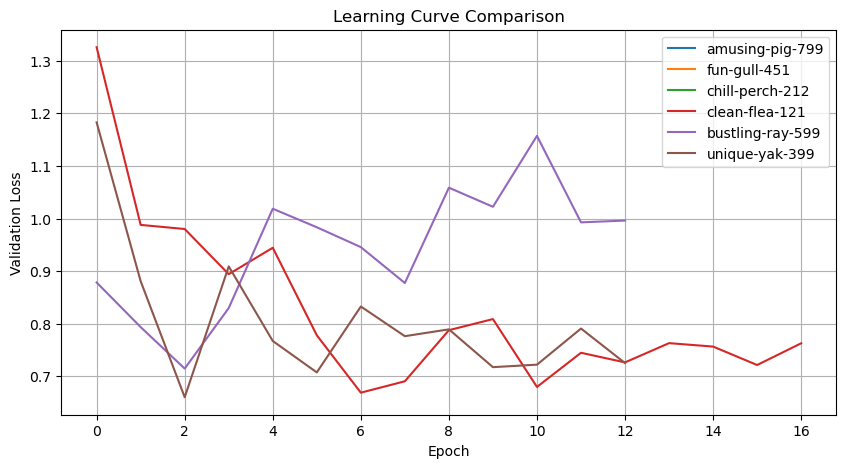

In [ ]:

plt.figure(figsize=(10, 5))

for _, run in summary_table.iterrows():
    run_id = run["run_id"]
    run_name = run["tags.mlflow.runName"]
    
    history = client.get_metric_history(run_id, "val_loss")
    steps = [m.step for m in history]
    values = [m.value for m in history]
    
    plt.plot(steps, values, label=run_name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Learning Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

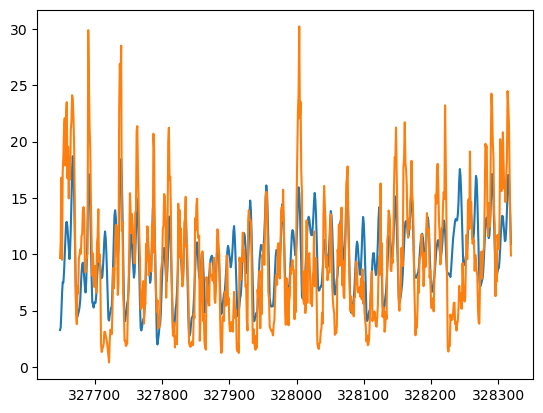

In [67]:
pred_path ="experiments/xLSTMMixer_90a5961e_ab874efe01114e18a05ce06be0214162/predictions.csv"
target_path = "experiments/xLSTMMixer_90a5961e_ab874efe01114e18a05ce06be0214162/target.csv"
df_pred = pd.read_csv(pred_path, index_col=0)
df_target = pd.read_csv(target_path, index_col=0)
groups_pred = df_pred.groupby("series_id")
groups_target = df_target.groupby("series_id")
unit_pred = groups_pred.get_group("unit_075")
unit_target = groups_target.get_group("unit_075")

plt.plot(unit_pred["target"])
plt.plot(unit_target["target"])
#plt.savefig("experiments/xLSTMMixer_90a5961e_ab874efe01114e18a05ce06be0214162/unit_075_preds.png", format='PNG')